In [6]:
# Step 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes as _load   # we'll use a different one
from sklearn.datasets import fetch_openml             # to load real diabetes data

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



In [7]:

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'pregnancies', 'glucose', 'blood_pressure',
    'skin_thickness', 'insulin', 'bmi',
    'diabetes_pedigree', 'age', 'diabetes'
]

df = pd.read_csv(url, names=columns)

print(" Dataset loaded!")
print(f"Shape: {df.shape}")
print()
df.head(10)


 Dataset loaded!
Shape: (768, 9)



,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [9]:

print("Dataset Info:")
print("=" * 40)
print(df.info())
print()
print("Basic Statistics:")
print("=" * 40)
print(df.describe().round(2))


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pregnancies        768 non-null    int64  
 1   glucose            768 non-null    int64  
 2   blood_pressure     768 non-null    int64  
 3   skin_thickness     768 non-null    int64  
 4   insulin            768 non-null    int64  
 5   bmi                768 non-null    float64
 6   diabetes_pedigree  768 non-null    float64
 7   age                768 non-null    int64  
 8   diabetes           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Basic Statistics:
       pregnancies  glucose  blood_pressure  skin_thickness  insulin     bmi  \
count       768.00   768.00          768.00          768.00   768.00  768.00   
mean          3.85   120.89           69.11           20.54    79.80   31.99   
std           3.37    31.97           19.36       

In [ ]:
cannot_be_zero = ['glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi']

print("Count of ZERO values (impossible in these columns):")
print("=" * 45)


for col in cannot_be_zero:
    zero_count = (df[col] == 0).sum()
    zero_pct = zero_count / len(df)*100
    print(f"  {col:<20}: {zero_count:>4} zeros  ({zero_pct:.1f}%)")
print("=" * 45)

Count of ZERO values (impossible in these columns):
  glucose             :    5 zeros  (0.7%)
  blood_pressure      :   35 zeros  (4.6%)
  skin_thickness      :  227 zeros  (29.6%)
  insulin             :  374 zeros  (48.7%)
  bmi                 :   11 zeros  (1.4%)


In [14]:
df_clean = df.copy()

for col in cannot_be_zero:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0,median_val)


print(" Zeros replaced with median values")
print()
print("Verification — minimums after cleaning:")
print("=" * 45)
for col in cannot_be_zero:
    print(f"  {col:<20}: min = {df_clean[col].min():.1f}")
print("=" * 45)    

 Zeros replaced with median values

Verification — minimums after cleaning:
  glucose             : min = 44.0
  blood_pressure      : min = 24.0
  skin_thickness      : min = 7.0
  insulin             : min = 14.0
  bmi                 : min = 18.2


Diabetes class distribution:
diabetes
0    500
1    268
Name: count, dtype: int64

diabetes
0    65.1
1    34.9
Name: proportion, dtype: float64


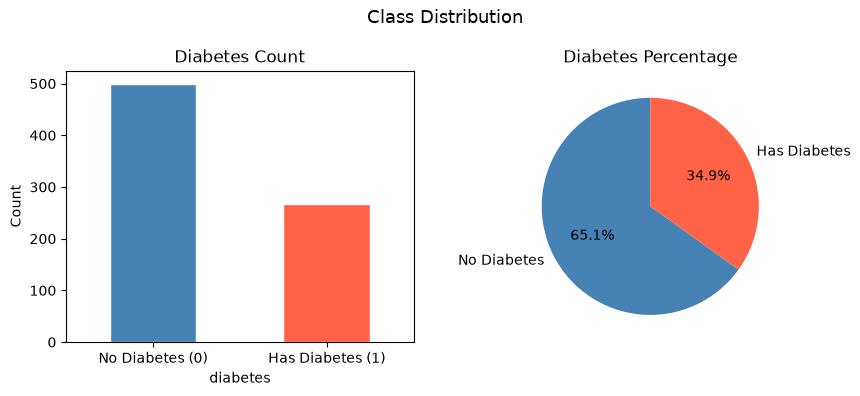

In [ ]:

print("Diabetes class distribution:")
print("=" * 40)
print(df_clean['diabetes'].value_counts())
print()
print(df_clean['diabetes'].value_counts(normalize=True).round(3) * 100)
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

df_clean['diabetes'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='white', width=0.5
)
axes[0].set_title("Diabetes Count")
axes[0].set_xticklabels(['No Diabetes (0)', 'Has Diabetes (1)'], rotation=0)
axes[0].set_ylabel("Count")

axes[1].pie(
    df_clean['diabetes'].value_counts().values,
    labels=['No Diabetes', 'Has Diabetes'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title("Diabetes Percentage")

plt.suptitle("Class Distribution", fontsize=13)
plt.tight_layout()
plt.show()


Final Data Health Check:
  Rows           : 768
  Columns        : 9
  Missing values : 0
  Duplicate rows : 0

Data types:
pregnancies            int64
glucose                int64
blood_pressure         int64
skin_thickness         int64
insulin              float64
bmi                  float64
diabetes_pedigree    float64
age                    int64
diabetes               int64
dtype: object


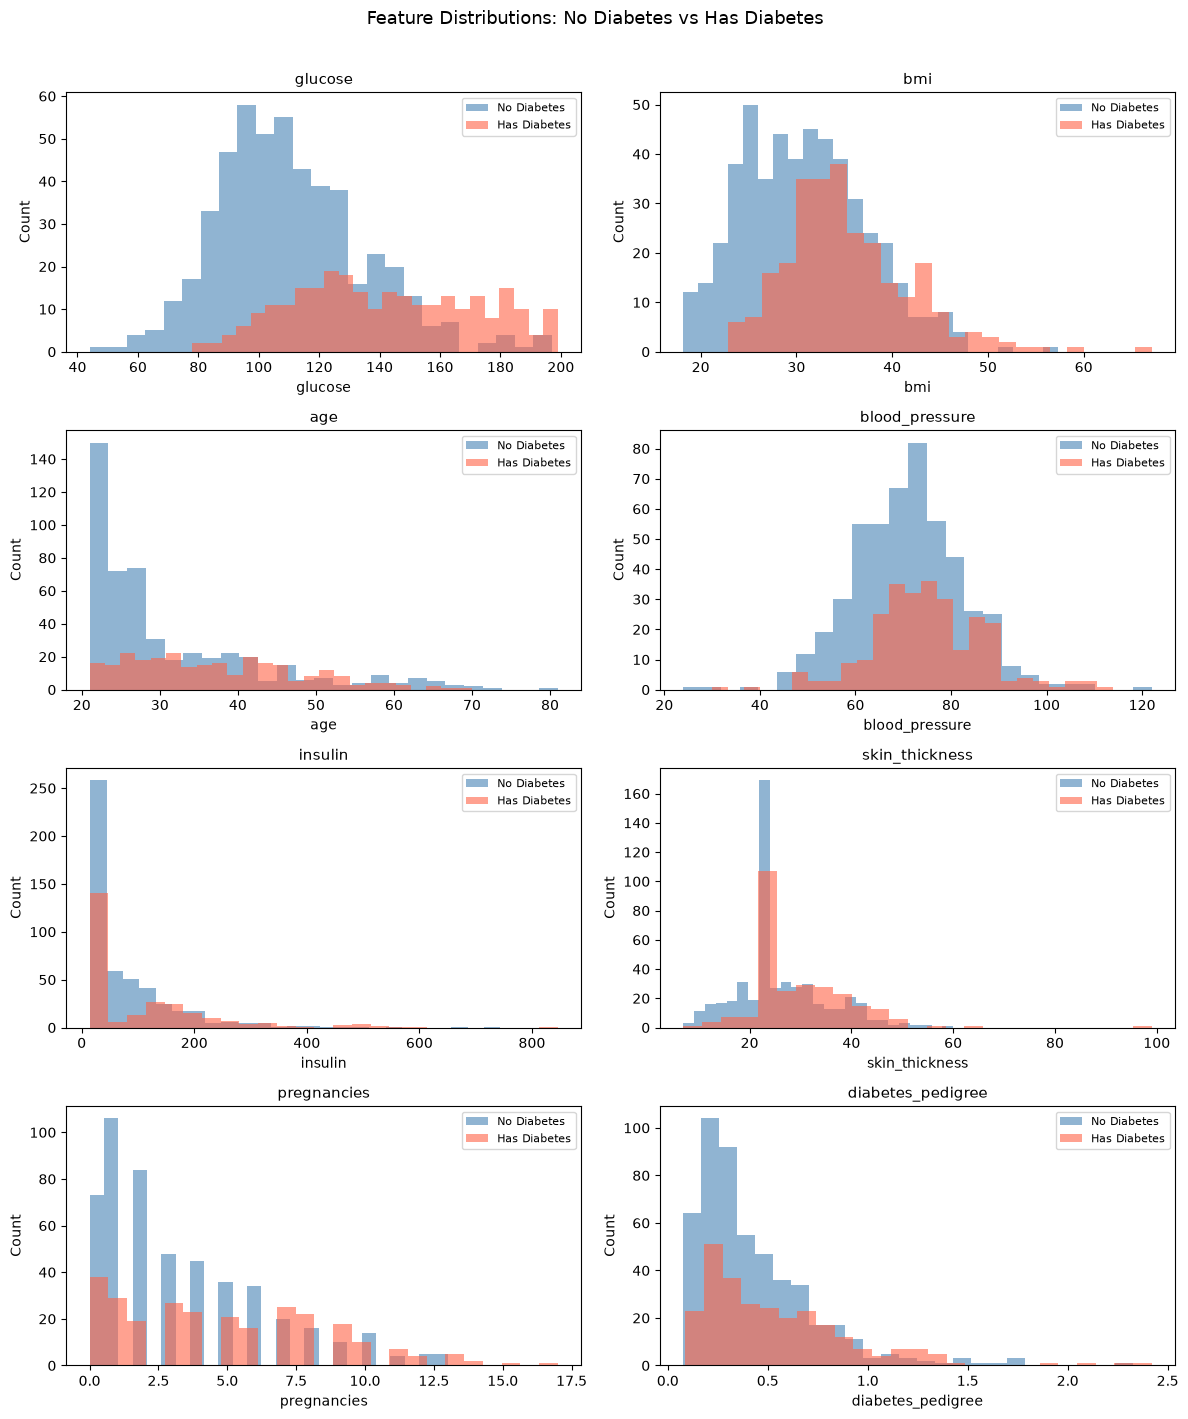

In [28]:
features = ['glucose', 'bmi', 'age', 'blood_pressure',
            'insulin', 'skin_thickness', 'pregnancies', 'diabetes_pedigree']



fig, axes = plt.subplots(4, 2, figsize=(12,14))
axes = axes.flatten()


no_diabetes = df_clean[df_clean['diabetes'] == 0]
has_diabetes = df_clean[df_clean['diabetes'] == 1]


for i, feature in enumerate(features):
    axes[i].hist(no_diabetes[feature],  bins=25, alpha=0.6,
                 color='steelblue', label='No Diabetes')
    axes[i].hist(has_diabetes[feature], bins=25, alpha=0.6,
                 color='tomato',    label='Has Diabetes')
    axes[i].set_title(f'{feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)


plt.suptitle("Feature Distributions: No Diabetes vs Has Diabetes",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()




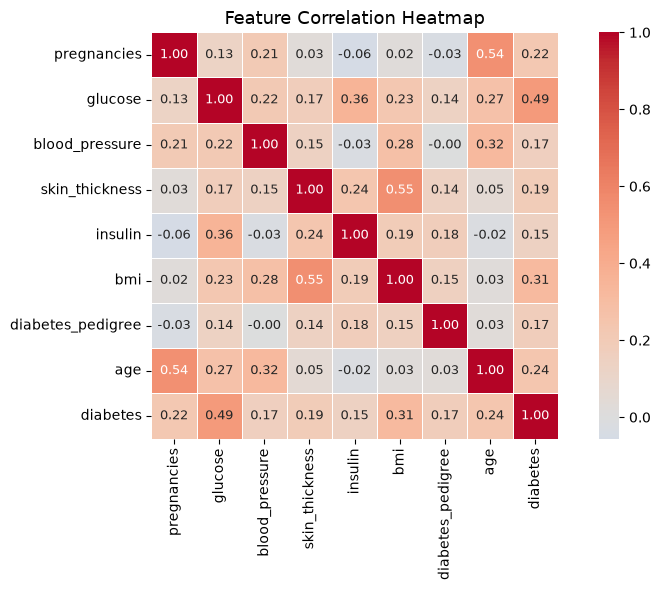

In [32]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    df_clean.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()

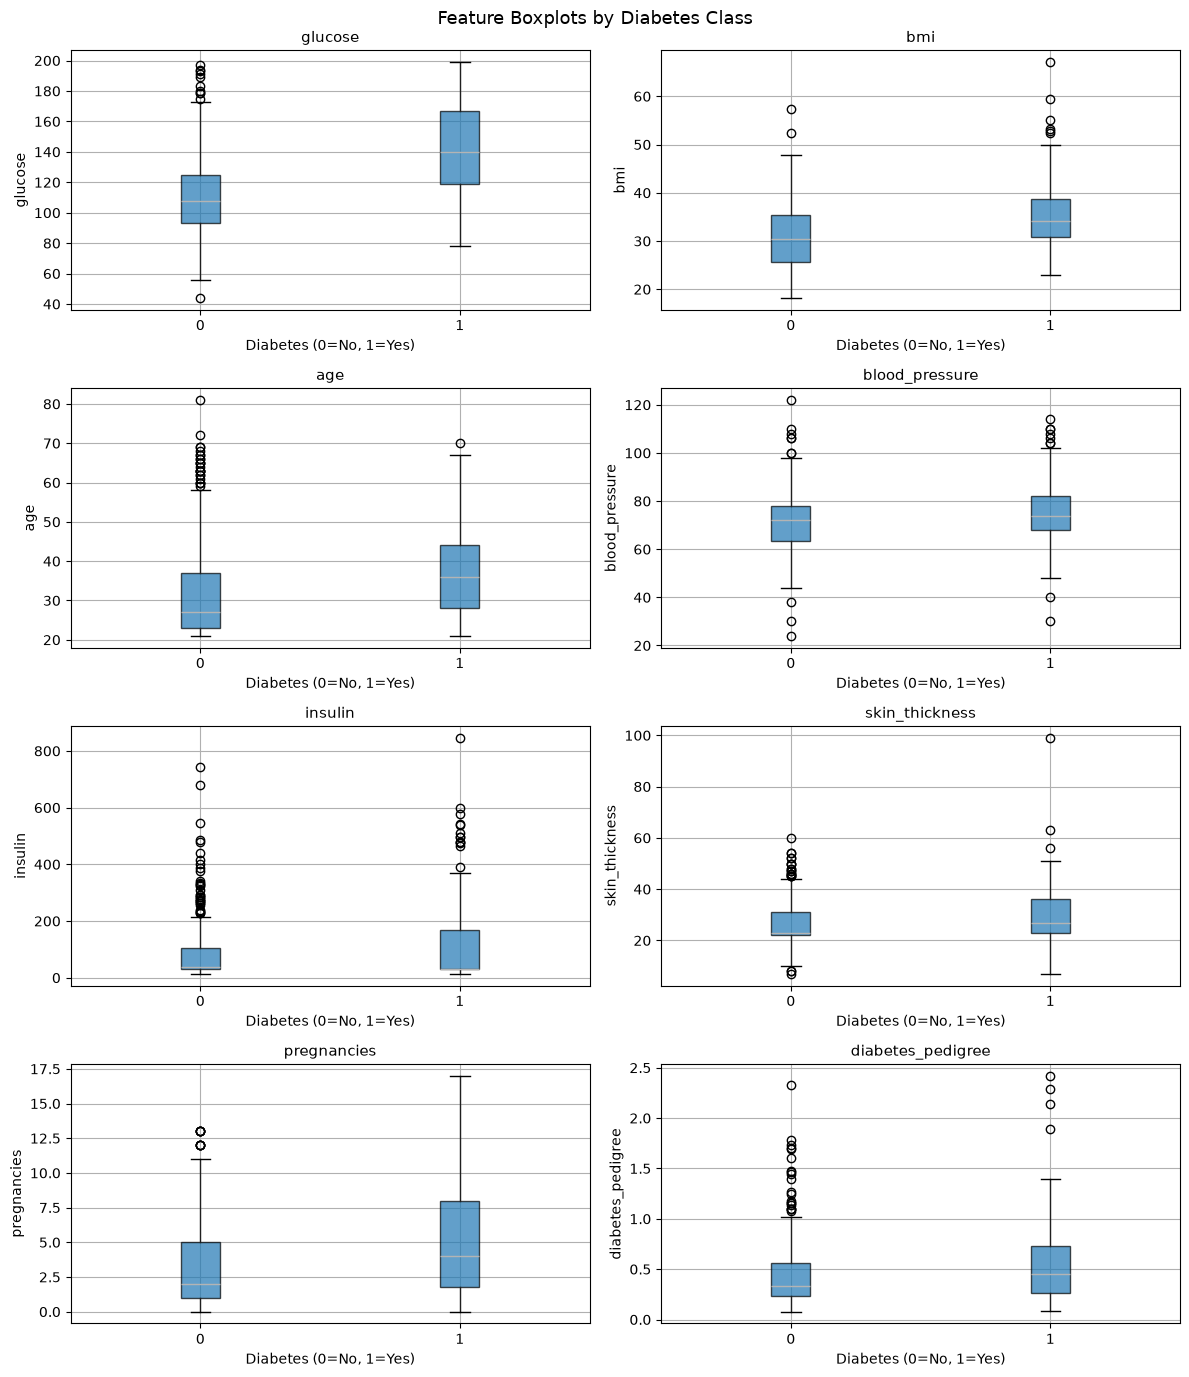

In [33]:

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()

for i, feature in enumerate(features):
    df_clean.boxplot(
        column=feature, by='diabetes',
        ax=axes[i], patch_artist=True,
        boxprops=dict(alpha=0.7)
    )
    axes[i].set_title(f'{feature}', fontsize=11)
    axes[i].set_xlabel('Diabetes (0=No, 1=Yes)')
    axes[i].set_ylabel(feature)

plt.suptitle("Feature Boxplots by Diabetes Class", fontsize=13)
plt.tight_layout()
plt.show()


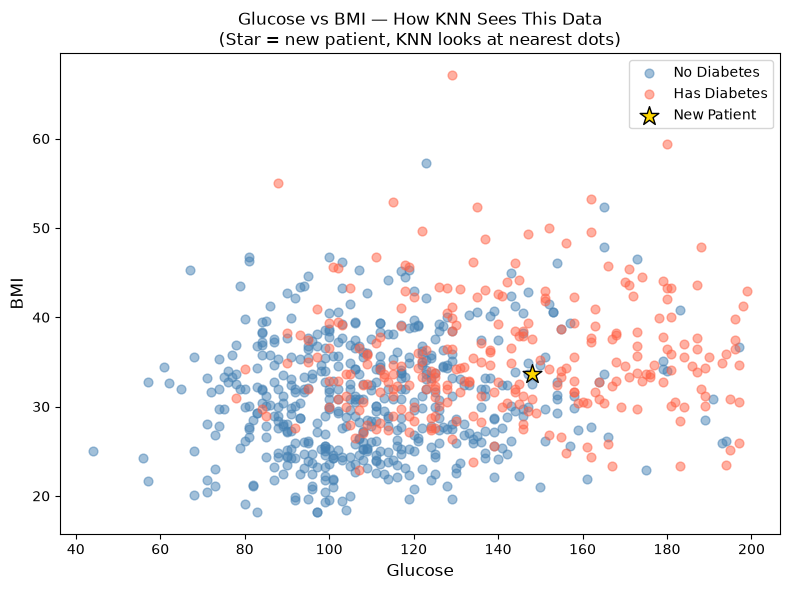

In [34]:

plt.figure(figsize=(8, 6))

plt.scatter(
    no_diabetes['glucose'], no_diabetes['bmi'],
    alpha=0.5, color='steelblue', label='No Diabetes', s=40
)
plt.scatter(
    has_diabetes['glucose'], has_diabetes['bmi'],
    alpha=0.5, color='tomato', label='Has Diabetes', s=40
)

# Mark a new patient
new_patient_glucose = 148
new_patient_bmi     = 33.6
plt.scatter(new_patient_glucose, new_patient_bmi,
            color='gold', s=200, marker='*',
            zorder=5, label='New Patient', edgecolors='black')

plt.xlabel("Glucose", fontsize=12)
plt.ylabel("BMI", fontsize=12)
plt.title("Glucose vs BMI — How KNN Sees This Data\n"
          "(Star = new patient, KNN looks at nearest dots)", fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:

print("UNSCALED feature ranges:")
print("=" * 45)
for col in features:
    print(f"  {col:<22}: {df_clean[col].min():.1f}  to  {df_clean[col].max():.1f}  "
          f"(range = {df_clean[col].max() - df_clean[col].min():.1f})")

print()
print("Problem for KNN:")
print("  insulin range    = 846 units")
print("  diabetes_pedigree range = 2.3 units")
print()
print("  Distance formula: sqrt((i1-i2)² + (d1-d2)² + ...)")
print("  insulin term:    (500-300)² = 40,000")
print("  pedigree term:   (1.5-0.5)² = 1")
print()
print("  insulin COMPLETELY DOMINATES the distance calculation!")
print("  pedigree is essentially IGNORED!")
print()
print("  After scaling: ALL features contribute equally ")


UNSCALED feature ranges:
  glucose               : 44.0  to  199.0  (range = 155.0)
  bmi                   : 18.2  to  67.1  (range = 48.9)
  age                   : 21.0  to  81.0  (range = 60.0)
  blood_pressure        : 24.0  to  122.0  (range = 98.0)
  insulin               : 14.0  to  846.0  (range = 832.0)
  skin_thickness        : 7.0  to  99.0  (range = 92.0)
  pregnancies           : 0.0  to  17.0  (range = 17.0)
  diabetes_pedigree     : 0.1  to  2.4  (range = 2.3)

Problem for KNN:
  insulin range    = 846 units
  diabetes_pedigree range = 2.3 units

  Distance formula: sqrt((i1-i2)² + (d1-d2)² + ...)
  insulin term:    (500-300)² = 40,000
  pedigree term:   (1.5-0.5)² = 1

  insulin COMPLETELY DOMINATES the distance calculation!
  pedigree is essentially IGNORED!

  After scaling: ALL features contribute equally ✅
